In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
df.sample(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1168,19,Female,Nepal,Undergraduate,TikTok,Entertainment,5.6,179,1.5,2.4,5.8,High,6.0
3543,21,Female,Canada,Undergraduate,Facebook,Networking,4.7,171,3.3,1.1,6.7,High,6.6
1241,21,Male,Italy,Undergraduate,Instagram,Entertainment,5.4,186,2.4,3.2,6.7,High,5.0
4811,20,Female,Other,Undergraduate,YouTube,Education,2.6,107,5.5,2.9,8.1,Low,7.3
2780,20,Female,Maldives,Undergraduate,Instagram,Entertainment,3.7,151,2.5,2.6,8.4,Medium,8.2


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.isna().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## EDA

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

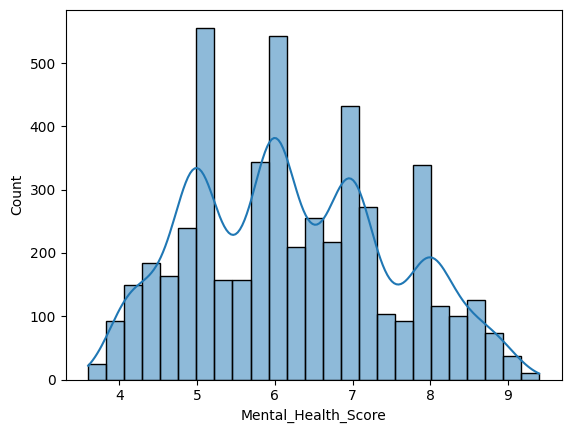

In [9]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

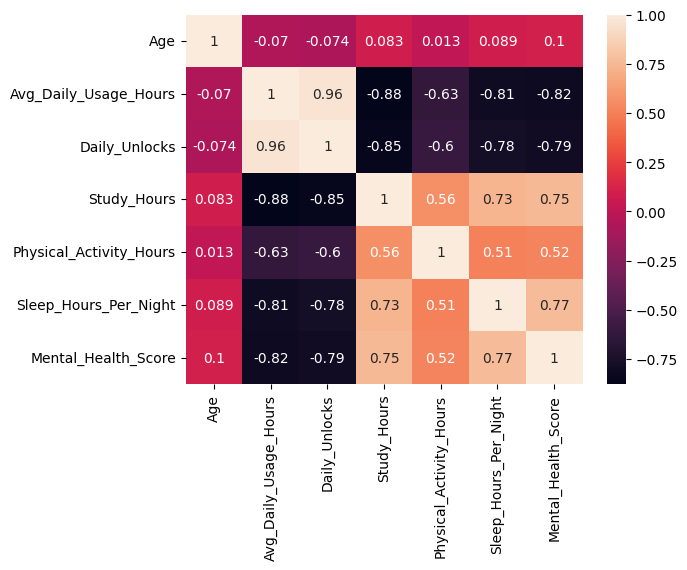

In [10]:
# correlation(Heat map- for numerical only)

sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
# stress level vs Mental Health Score

print(df['Stress_Level'].unique())

['Medium' 'Low' 'Very High' 'High']


<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

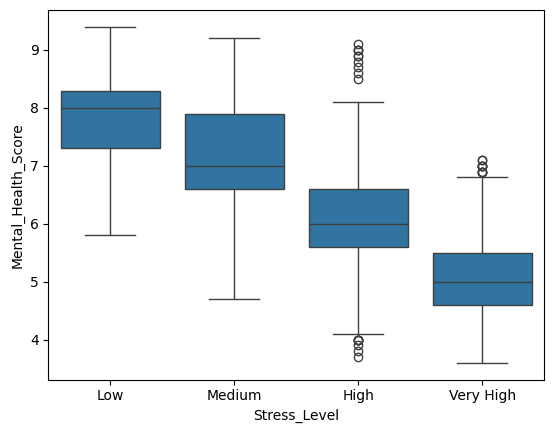

In [12]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

In [13]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

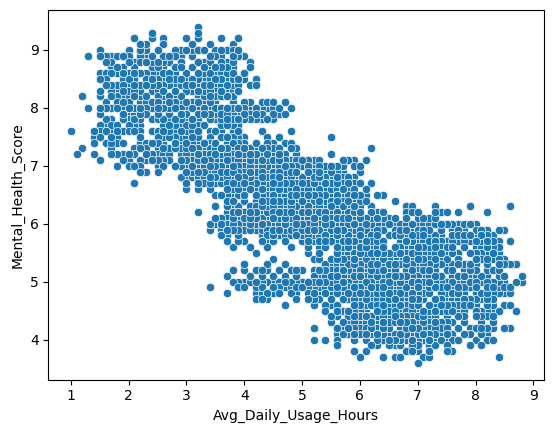

In [14]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y= 'Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

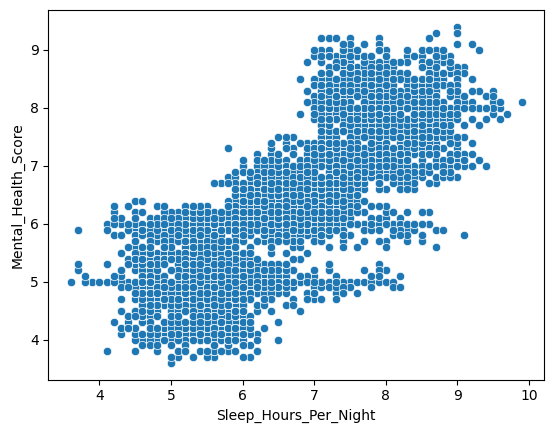

In [15]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y= 'Mental_Health_Score',data=df)

In [16]:
# platforms

df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

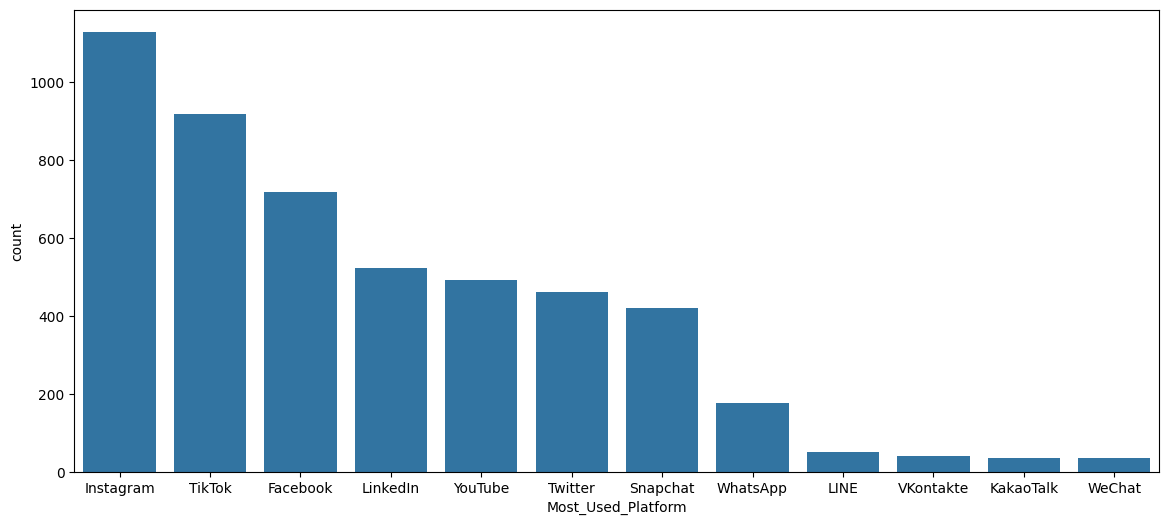

In [17]:
plt.figure(figsize=(14,6))
sns.countplot(x='Most_Used_Platform',data=df,order=df['Most_Used_Platform'].value_counts().index)

In [18]:
# checking outliar

num_features=df.select_dtypes(include='number')
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


checking outliers

In [19]:

Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers=((num_features < lower_bound) | (num_features > upper_bound))
outliers.sum()

,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


## data cleaning

In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [21]:
df.shape

(5000, 13)

In [22]:
# drop duplicate rows
df=df.drop_duplicates()

# converting the negative or unrealistic value to the realistic(Clipping)

df['Physical_Activity_Hours']= df['Physical_Activity_Hours'].clip(lower=0)


In [23]:
df.shape

(4998, 13)

In [24]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Skewness

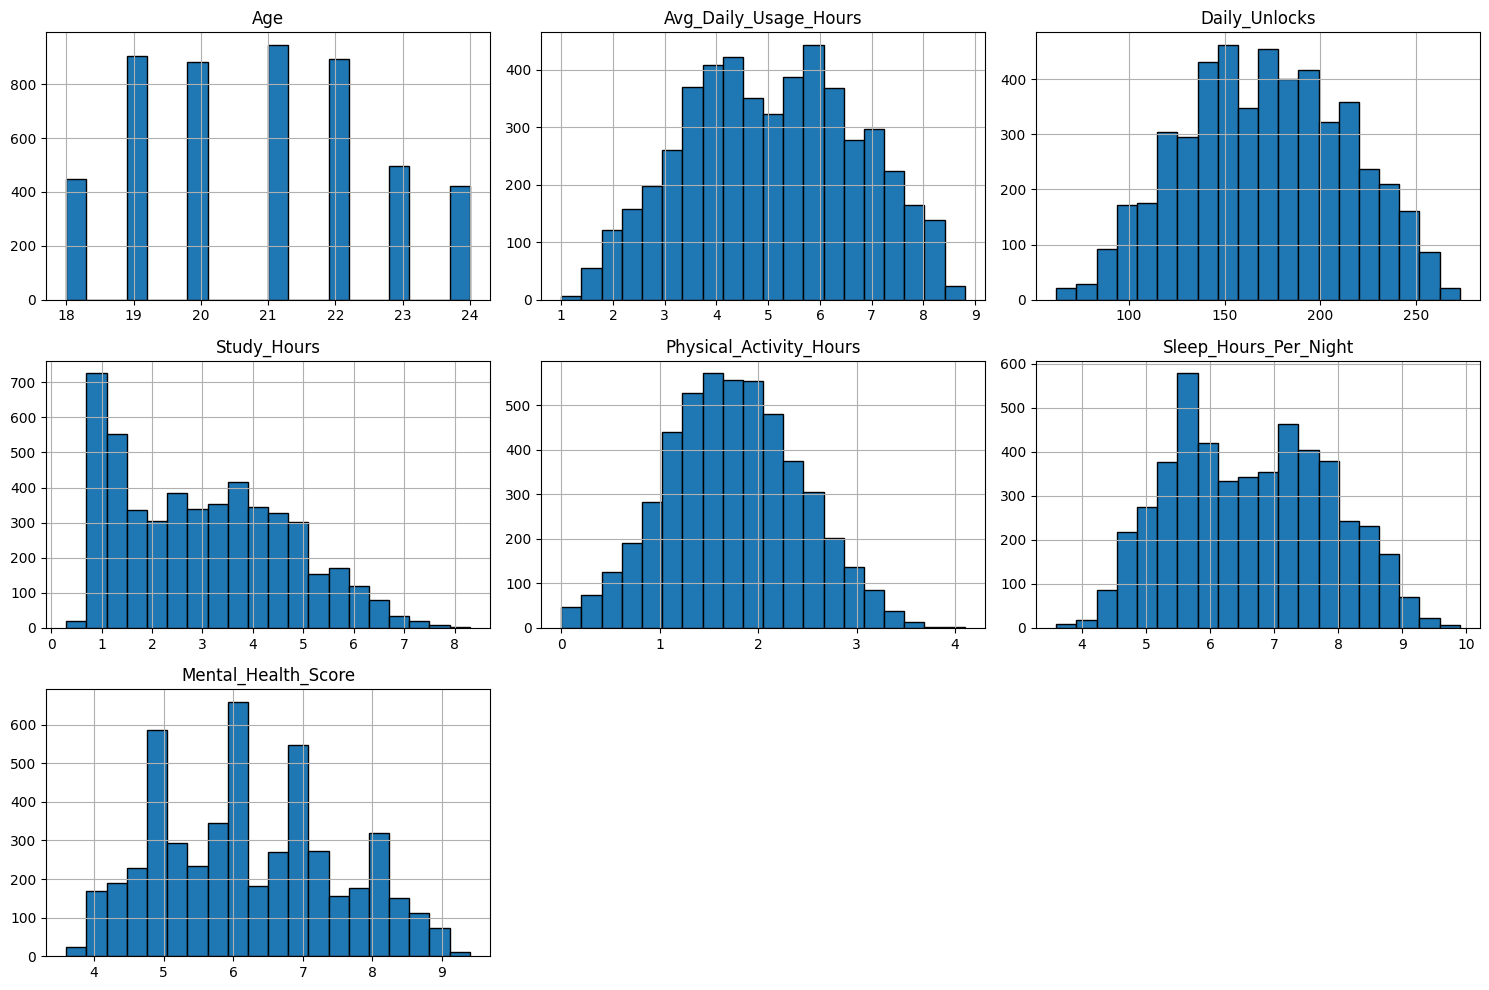

In [25]:
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

In [26]:
num_cols = df.select_dtypes(include=['number'])
num_cols.skew()


,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [27]:
# to fix 'study hour' use log transformation

## Feature Engineering

In [28]:
df['Country'].value_counts()

,count
Country,
Other,1879
India,389
USA,354
Canada,230
Australia,198
...,...
Armenia,1
Bosnia,1
Kuwait,1


In [29]:
top_countries=df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [30]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [31]:
df['Grouped_country']=df['Country'].apply(group_countries)

In [32]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [33]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [34]:
df.shape

(4998, 14)

In [35]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


## Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

skwed_col=['Study_Hours']
other_numeric_cols=['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_col=['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_country']

feature_col=skwed_col + other_numeric_cols + ordinal_col + normal_col

x=df[feature_col]
y=df['Mental_Health_Score']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [37]:
x_train.shape

(3498, 12)

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer , StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

normal_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])



preprocessor=ColumnTransformer(transformers=[
    ('Skewed_Pipeline',skew_pipeline,skwed_col),
    ('Plain_Numeric',plain_numeric_pipeline,other_numeric_cols),
    ('Ordinal',ordinal_pipeline,ordinal_col),
    ('Normal',normal_pipeline,normal_col)
])



In [46]:
preprocessor

ColumnTransformer(transformers=[('Skewed_Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain_Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Normal',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped_country'])])

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Plain_Numeric',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night']),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('regressor', LinearRegression())])

In [48]:
# performance on the testing data

lr_preds_test=lr_pipeline.predict(x_test)

lr_mse_testing=mean_squared_error(y_test,lr_preds_test)
lr_r2_testing=r2_score(y_test,lr_preds_test)
lr_mae_testing=mean_absolute_error(y_test,lr_preds_test)

print(f'MSE: {lr_mse_testing}')
print(f'R2: {lr_r2_testing}')
print(f'MAE: {lr_mae_testing}')

MSE: 0.45701905273488
R2: 0.739794461743302
MAE: 0.5361775634720183


In [49]:
# Performance  on training data

lr_preds_train=lr_pipeline.predict(x_train)

lr_mse_training=mean_squared_error(y_train,lr_preds_train)
lr_r2_training=r2_score(y_train,lr_preds_train)
lr_mae_training=mean_absolute_error(y_train,lr_preds_train)

print(f'MSE: {lr_mse_training}')
print(f'R2: {lr_r2_training}')
print(f'MAE: {lr_mae_training}')

MSE: 0.43678483385828654
R2: 0.7236771199387538
MAE: 0.5189846926901907


## Random Forest (Default parameter)

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Plain_Numeric',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hour...ht']),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [51]:
# performance on test data

rf_preds_test=rf_pipeline.predict(x_test)

rf_mse_testing=mean_squared_error(y_test,rf_preds_test)
rf_r2_testing=r2_score(y_test,rf_preds_test)
rf_mae_testing=mean_absolute_error(y_test,rf_preds_test)

print(f'MSE: {rf_mse_testing}')
print(f'R2: {rf_r2_testing}')
print(f'MAE: {rf_mae_testing}')

MSE: 0.21500011819333337
R2: 0.8775888638668996
MAE: 0.34722113333333343


In [52]:
# performance on train data

rf_pred_train=rf_pipeline.predict(x_train)

rf_mse_train=mean_squared_error(y_train,rf_pred_train)
rf_r2_train=r2_score(y_train,rf_pred_train)
rf_mae_train=mean_absolute_error(y_train,rf_pred_train)

print(f'MSE: {rf_mse_train}')
print(f'R2: {rf_r2_train}')
print(f'MAE: {rf_mae_train}')

MSE: 0.030304012178387706
R2: 0.9808287942404612
MAE: 0.12653287592910242


## Hyperparameter Tuning the random Forest

In [53]:
# To get best parameter

param_grid= {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf':[1,2,4]
}

from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1  # use all free processor
)

In [54]:
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10, 15],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, scoring='r2')

In [55]:
random_search.best_params_

{'regressor__n_estimators': 200,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [56]:
rf_best_pipeline=random_search.best_estimator_
rf_best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Plain_Numeric',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hour...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=2,
                                       min_samples_split=5, n_estimators=200,
                                       random_state=42))])

In [57]:
rf_best_preds=rf_best_pipeline.predict(x_test)

print(f"r2_score:{r2_score(y_test,rf_best_preds)}")
print(f"mse:{mean_squared_error(y_test,rf_best_preds)}")
print(f"mae:{mean_absolute_error(y_test,rf_best_preds)}")

r2_score:0.8650140569761653
mse:0.23708622124874948
mae:0.3689015766630922


In [58]:
# import joblib
# joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')